In [2]:
import numpy as np

import matplotlib.pyplot as plt
from scipy.special import spherical_jn

import sys
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

#### Overburden calculation from Dave

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

(0.1, 100000.0)

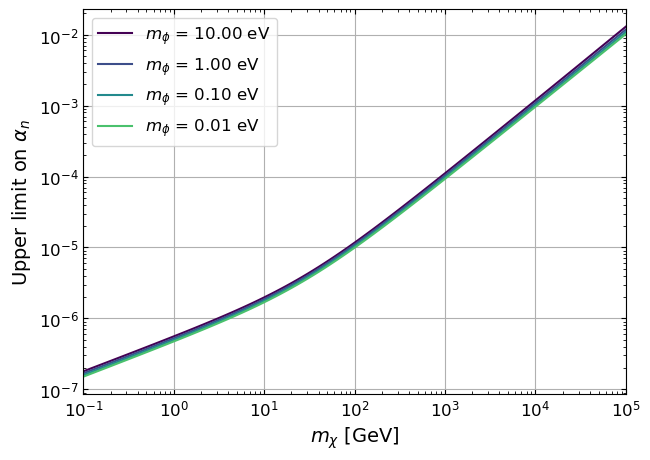

In [4]:
mgas = 28 ## GeV
n0 = 1.96e-22 ## GeV^3
H0 = 5.2e19 ## GeV^-1
v0 = 1e-3

mphi_list = [10e-9, 1e-9, 0.1e-9, 0.01e-9] ## GeV
mchi_list = np.logspace(-1, 5, 100)

def ffn(x_in, mx, mp):

    mu = mx*mgas/(mx + mgas)

    x = 10**x_in
    logarg = (1 + (mu*v0**2/(2*x*mp))**2)
    #logarg = (1 + (mx*v0**2/(2*x*mp))**1)
    #print(logarg)
    #if(np.isinf(logarg)):
    #    logarg = 1e40
    return  (8 * np.pi * mu * x**2 * n0 * H0/(mgas * mx**2 * v0**4)  * np.log(logarg) - 0.1)**2
    #return  (8 * np.pi * mu * x**2 * n0 * H0/(mx * mx**2 * v0**4)  * np.log(logarg) - 0.1)**2

plt.figure()

for mphi in mphi_list:

    curr_alphas = []
    for mchi in mchi_list:

        res = minimize_scalar(ffn, args=(mchi, mphi), bounds=[-10, 1], method='bounded')
        if res.success and res.fun < 0.01:
            curr_alphas.append(res.x)
        else:
            print("Warning, failed to find root")
            curr_alphas.append(np.nan)
    curr_alphas = np.array(curr_alphas)
    plt.loglog(mchi_list, 10**curr_alphas, label=r'$m_{\phi}$ = %.2f eV'%(mphi*1e9))

plt.legend()
plt.xlabel(r'$m_{\chi}$ [GeV]')
plt.ylabel(r'Upper limit on $\alpha_n$')
plt.grid(True)
plt.xlim(1e-1, 1e5)

#### Modifying Dave's code to the correct formulae

(0.1, 1000000.0)

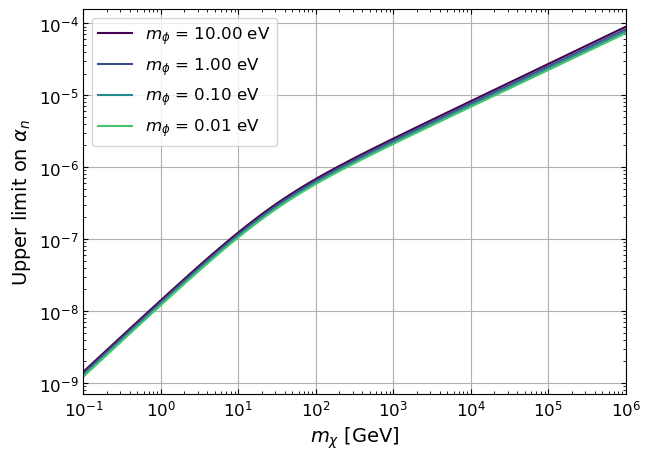

In [19]:
mgas = 28 ## GeV
n0 = 1.96e-22 ## GeV^3
H0 = 5.2e19 ## GeV^-1
v0 = 1e-3

mphi_list = [10e-9, 1e-9, 0.1e-9, 0.01e-9] ## GeV
mchi_list = np.logspace(-1, 6, 100)

def ffn(x_in, mx, mp):

    mu = mx*mgas/(mx + mgas)

    x = 10**x_in
    logarg = (1 + (mu*v0**2/(2*x*mp))**2)
    
    return  (2 * np.pi * x**2 * n0 * H0 / (mx * mu * v0**4)  * np.log(logarg) - 0.1)**2

plt.figure()

for mphi in mphi_list:

    curr_alphas = []
    for mchi in mchi_list:

        res = minimize_scalar(ffn, args=(mchi, mphi), bounds=[-10, 1], method='bounded')
        if res.success and res.fun < 0.01:
            curr_alphas.append(res.x)
        else:
            print("Warning, failed to find root")
            curr_alphas.append(np.nan)
    curr_alphas = np.array(curr_alphas)
    plt.loglog(mchi_list, 10**curr_alphas/14, label=r'$m_{\phi}$ = %.2f eV'%(mphi*1e9))

plt.legend()
plt.xlabel(r'$m_{\chi}$ [GeV]')
plt.ylabel(r'Upper limit on $\alpha_n$')
plt.grid(True)
plt.xlim(1e-1, 1e6)

## Classical calculation (momentum transfer cross section)

In [20]:
# Parameters
hbarc = 0.2     # eV um
kg2GeV = 5.61e26
v0 = 1e-3    # DM velocity

m_n = 1e9      # neutron mass (eV)
m_N = m_n * 28 # Nitrogen mass (eV)

m_total_atmosphere = 5.15e18  # total mass of the atmosphere (kg)
n_nitrogen_atmosphere = m_total_atmosphere * kg2GeV / 28   # total number of nitrogen in the atmosphere
r_earth = 6.4e6    # Earth radius (m)
r_nitrogen = 8500 # Nitrogen distribution length (m)

r_earth_ev = r_earth / 1e-6 / hbarc
r_nitrogen_ev = r_nitrogen / 1e-6 / hbarc
n_tot_nitrogen_path = n_nitrogen_atmosphere / (4 * np.pi * r_earth_ev**2)                # total number of nitrogen along the path
n_nitrogen_volume = n_nitrogen_atmosphere / (4 * np.pi * r_earth_ev**2 * r_nitrogen_ev)  # volume number density of nitrogen (eV^-3)

# Reference cross section for Coulomb scattering

# m_X = 10e9   # Nugget mass (eV)
# R_X = 1e-3 / hbarc # Nugget radius (assume to be 1 nm)
# mu_Xn = 1 / (1/m_n + 1/m_X)  # nugget-neutron reduced mass
# mu_XN = 1 / (1/m_N + 1/m_X)  # nugget-nitrogen reduced mass
# q0 = v0 * mu_Xn  # reference momentum transfer
# alpha_n = 1e-5      # Single neutron coupling of a nugget

# sig_0 = 4 * np.pi * alpha_n**2 * mu_Xn**2 / (q0**4)

Consdier scattering of DM and N2 molecules via a Yukawa potential
$$
V(r) = \alpha \frac{e^{-r / \lambda}}{r},
$$
we will treat DM and air molecules as point charges. This is valid as long as the interaction length $\lambda$ is much larger than the physical sizes of DM particles and air molecules.
The interaction length is chosen as $\lambda$ = min[$1/m_\phi$, $l$] where $l$ is the mean free path of air molecules in the atmosphere. In other words, interaction with much longer range is still cut off by the random motion of air molecules.

We estimate momentum transfer in the colllision using approximate formulaes for momentum transfer cross section. The momentum transfer cross section is defined as
$$
    \sigma_T \equiv \int d \Omega (1 - \cos \theta) \frac{d \sigma}{d \Omega},
$$
which weights the fractional change in momentum by the differential scattering cross section ($\theta$ is the scattering angle in the CM frame for the effective one-body problem).
In the relevant parameter space, we're always working in the classical regime ($\mu v \lambda \gg 1$, where $\mu$ is the reduced mass and $v$ is the relative velocity) where the potential is weak ($\beta \equiv \alpha / \mu v^2 \lambda \lesssim 1$). In this limit, the transfer cross section for a repulsive potential is approximately given by
$$
    \sigma_T \approx 2 \pi \lambda^2 \beta^2 \mathrm{log}(1 + \beta^{-2}).
$$

Consider a DM particle with velocity $\vec{v}_0$ moving through a background gas of air molecules at rest.
The problem reduces to scattering of mass $\mu$ with initial velocity $\vec{v}_0$ off a fixed potential in the center-of-mass frame.
The direction of the $\vec{v}_0$ does not change on average, while the absolute value decreases in each collision.


The distribution of scattering angle is given by $\sigma^{-1} d \sigma /d \Omega$. The averaged change in parallel velocity is then
$$
    \langle \Delta v_\parallel \rangle = \frac{v_0}{\sigma} \int \frac{d \sigma}{d \theta} (1 - \cos \theta) d \Omega = \frac{\sigma_T v_0}{\sigma}.
$$
The scattering is symmetric in the azimuthal angle $\phi$ so $\langle \Delta v_\perp \rangle = 0$.
The average momentum transfer from the DM particle to the air molecule is $\langle \Delta p \rangle = \mu \langle \Delta v_\parallel \rangle$.


Transfering back to the lab frame, the rate that the DM particle loses its momentum is
$$
    \frac{\dot{p}}{p} = n_\mathrm{atm} v_0 \sigma \langle \Delta p \rangle / (M_\chi v_0) = n_\mathrm{atm} \sigma_T v_0 (\mu / M_\chi),
$$
where $n_\mathrm{atm}$ is the number density of the atmosphere molecules.

In [21]:
def calc_alpha_n_stop_classical(mx):
    b_min = 1e-5 / hbarc
    b_max = 1 / hbarc

    alpha_n_list = np.logspace(-3, -20, 200)

    stop_fractions = np.empty_like(alpha_n_list)
    for i, alpha_n in enumerate(alpha_n_list):
        alpha = alpha_n * 14  # DM-N2 coupling

        dEdx_classical = n_nitrogen_volume * 4 * np.pi * alpha**2 / (m_N * v0**2) * np.log(b_max / b_min)

        ek_dm = 0.5 * mx * v0**2
        stop_fractions[i] = ek_dm / (dEdx_classical * r_nitrogen_ev)
    return np.interp(1, stop_fractions, alpha_n_list)

def calc_alpha_n_stop(mx, mphi):
    # Assume the very long range interaction would be cut off
    # at the scale of mean free path of air molecule
    # l ~ 100 nm ~ 2 eV-1
    screening_length = 2    # eV-1
    if mphi == 0:
        lamb = screening_length
    else:
        lamb = min(1/mphi, screening_length)
        # lamb = 1 / mphi

    alpha_n_list = np.logspace(-3, -20, 200)
    stop_fractions = np.empty_like(alpha_n_list)

    for i, alpha_n in enumerate(alpha_n_list):
        alpha = alpha_n * 14
        mu_XN = 1 / (1/m_N + 1/mx)

        # Beta parameter for the potential
        beta = alpha / (mu_XN * v0**2 * lamb)
        # Transport cross section
        sigma_transport = 2 * np.pi * lamb**2 * beta**2 * np.log(1 + 1/(beta**2))

        v_cm = v0
        pdot_p = (mu_XN / mx) * n_nitrogen_volume * sigma_transport * v_cm
        delta_t_pass = r_nitrogen_ev / v0

        stop_fractions[i] = 1 / (pdot_p * delta_t_pass)

    return np.interp(1, stop_fractions, alpha_n_list)

In [22]:
mphi_list = [10, 1, 0.1, 0]  # eV
mx_list = np.logspace(-1, 6, 100) * 1e9

alpha_n_stop = np.empty(shape=(len(mphi_list), mx_list.size))
for i, mphi in enumerate(mphi_list):
    for j, mx in enumerate(mx_list):
        alpha_n_stop[i, j] = calc_alpha_n_stop(mx, mphi)

alpha_n_stop_classical = np.empty_like(mx_list)
for i, mx in enumerate(mx_list):
    alpha_n_stop_classical[i] = calc_alpha_n_stop_classical(mx)

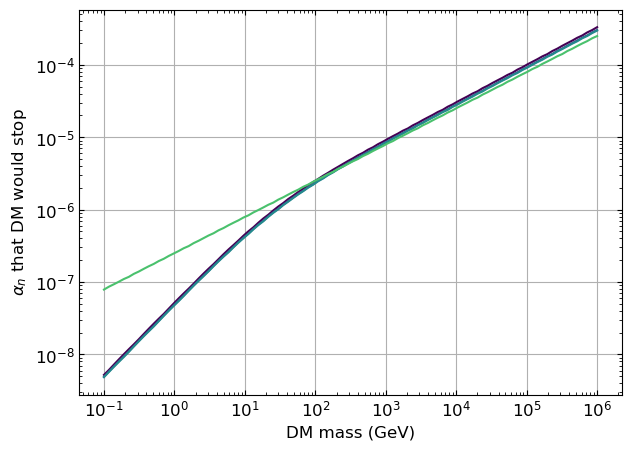

In [23]:
for i in range(3):
    plt.loglog(mx_list/1e9, alpha_n_stop[i])

plt.loglog(mx_list/1e9, alpha_n_stop_classical)

plt.xlabel('DM mass (GeV)', fontsize=12)
plt.ylabel(r'$\alpha_n$ that DM would stop', fontsize=12)

plt.grid()

## Below are some earlier attempts

In [ ]:
def dsig_domega_born(mx, mphi, alpha, q, R=None, point_charge=True):
    """
    Differential cross section given by Born approximation

    :param mx : DM mass in natural units
    :param phi: mediator mass
    :param q  : momentum transfer (array_like)
    :param R  : radius that goes into the form factor, None if point charge
    :param point_charge: if True give point charge solution
                         if False include a uniform sphere form factor

    :return: dsigma/domega in natural units (array_like)
    """
    point_charge_sol = (4 * (mx**2) * (alpha**2) ) / ( (mphi**2 + q**2)**2 )
    if point_charge:
        return point_charge_sol
    else:
        form_factor = 3 * spherical_jn(n=1, z=q*R) / (q * R)
        return point_charge_sol * form_factor**2

#### Classical calculation (Bethe-like formula)

Assume a point charge DM with velocity $v_0$ is moving through point charge N2 molecules at rest through a Coulomb potential $V(r) = \alpha / r$. If the DM particle moves really fast, the momentum transfer and energy loss when it pass through a nitrogen molecule is
$$
    \Delta p (b) \approx 2 \alpha / (b v_0), \quad \Delta E (b) = \Delta p / (2 m_N) \approx 2 \alpha^2 / (m_N b^2 v_0^2),
$$
where $b$ is the impact parameter and $m_N$ is the mass of the N2 molecule.

The averaged energy loss per unit distance is
$$
    \langle \frac{dE}{dx} \rangle = n \int^{b_{max}}_{b_{min}} db \cdot 2 \pi b \Delta E (b) = n \cdot 4 \pi \frac{\alpha^2}{m_N v_0^2} \mathrm{log} (\frac{b_{max}}{b_{min}}),
$$
where $n$ is the number density of the nitrogen molecules.

Here we assume $b_{min} \sim 10^{-11} \ \mathrm{m}$ (below which the DM starts to probe the nuclear structure) and $b_{max} \sim 30 \ \mu\mathrm{m}$ (this is the length scale the thermal collisions of other gases would push the molecule around during the scattering). Note that the integral is very sensitive to $b_{max}$.

In [ ]:
# b_min = alpha / (2 * mu_XN * v0)
b_min = 1e-9 / hbarc
# b_max = 30 / hbarc

mx_list = np.logspace(-1, 6, 100) * 1e9
alpha_n_list = np.logspace(-7, -3, 5)

stop_fractions_classical = np.empty((alpha_n_list.size, mx_list.size))
for i, alpha_n in enumerate(alpha_n_list):
    alpha = alpha_n * 14  # DM-N2 coupling

    b_max = np.sqrt(2 * alpha**2 / (m_N * v0**2 * 0.289))
    dEdx_classical = n_nitrogen_volume * 4 * np.pi * alpha**2 / (m_N * v0**2) * np.log(b_max / b_min)

    ek_dm = 0.5 * mx_list * v0**2
    stop_fractions_classical[i] = ek_dm / (dEdx_classical * r_nitrogen_ev)


#### Quantum calculation (loosely after Appendix A of https://arxiv.org/pdf/1812.07573)

The averaged energy loss per collision of a DM particle and a N2 molecule can be written as
$$
    \langle \Delta E \rangle = \frac{1}{\sigma_{XN}} \int d\omega dq \cdot \omega \frac{d \sigma_{XN}}{dq d\omega} \cdot \delta(\omega - \frac{q^2}{2 m_N}),
$$
where $\sigma_{XN} = \int d\omega dq \ \frac{d \sigma_{XN}}{dq d\omega}$ is the total scattering cross section per unit length of traveling.

We write the differential cross section as
$$
    \frac{d \sigma}{dq d\omega} = \frac{d \bar{\sigma}}{dq d\omega} |F_X(q)|^2,
$$
where $\frac{d \bar{\sigma}}{dq d\omega}$ is the differential cross section in the case DM is treated as a point charge and $F_X (q) = 3 j_1(q R_X) / (q R_X)$ is the DM form factor ($R_X$ is the DM radius). We will always treat the N2 molecules as point charges.

Using the Born approximation, we have the differential cross section
$$
    \frac{d \bar{\sigma}}{dq d\omega} = \frac{2 \pi q}{p^2} \frac{d \bar{\sigma}}{d \Omega} = (\frac{2 \pi q}{p^2}) \frac{4 \mu^2_{XN} \alpha^2}{q^4},
$$
where $p = m_X v_0$ is the momentum carried by DM and $\mu_{XN}$ is the DM-N2 reduced mass. Note that this expression is valid only when the momentum transfer is small $q \ll p$. The nuclear coherence is captured in the $\sim \alpha^2 \sim A^2$ scaling, which means the scattering is always coherent over the entire N2 molecule (in the DM literature this is often represented by a material sturctural function $S(q, \omega) \sim A^2 \delta(\omega - \frac{q^2}{2 m_N})$).

Now the averaged energy loss per unit distance is
$$
    \langle \frac{dE}{dx} \rangle \approx \mathrm{min}[n \sigma_{XN}, n^{1/3}]  \cdot \langle \Delta E \rangle,
$$
where we have taken into consideration the possibility that DM scatter with every molecules it meets when the cross section is sufficiently large (https://arxiv.org/pdf/1803.08044). The $n^{1/3}$ expression is valid only when the inverse momentum transfer is much larger than the distance between scattering sites, which is *not* always the case in our parameter space.

Similar to the classical calculation, the integral is very sensitive to the minimum momentum transfer $q_{min}$ that we consider. I very crudely use $q_{min} \sim (2 \alpha) / ((30  \ \mu \mathrm{m}) \cdot v_0) \lesssim 0.01 \ \mathrm{eV}$ in the following calculation but am unsure about when the calculation would break down.

In [ ]:
def dEdx_born(alpha_n, mx, qmin, qmax, point_charge=True, R=None):
    mu_XN = 1 / (1/m_N + 1/mx)  # nugget-nitrogen reduced mass

    alpha = alpha_n * 14
    qq = np.linspace(qmin, qmax, 500)

    dsigdomega = dsig_domega_born(mx=mu_XN, mphi=0, alpha=alpha, q=qq, R=R, point_charge=point_charge)

    p = mx * v0
    dsdq = ( 2 * np.pi * qq / (p**2) ) * dsigdomega

    dsdq[qq > 2 * p] = 0

    delta_e = qq**2 / (2 *  mu_XN)
    dE = np.trapz(y=(delta_e * dsdq), x=qq)

    sig_tot = np.trapz(y=dsdq, x=qq)
    factor = min(n_nitrogen_volume * sig_tot, n_nitrogen_volume**(1/3))

    return dE * factor


In [ ]:
stop_fractions_point = np.empty((alpha_n_list.size, mx_list.size))
stop_fractions_nugget = np.empty((alpha_n_list.size, mx_list.size))

for i, alpha_n in enumerate(alpha_n_list):
    for j, mx in enumerate(mx_list):
        alpha = alpha_n * 14
        mu_XN = 1 / (1/m_N + 1/mx)
        
        # q_min = np.sqrt(2 * m_N * 0.01)
        # q_min = 1000
        # q_min = 100
        q_min = 2 * alpha / ((30/hbarc) * v0)
        q_max = 2 * mu_XN * v0

        ek_dm = 0.5 * mx * v0**2

        dEdx_point = dEdx_born(alpha_n, mx, q_min, q_max, True, None)
        
        # Assume composite DM has radius 0.01 eV^-1 (2 nm)
        dEdx_nugget = dEdx_born(alpha_n, mx, q_min, q_max, False, 1e-2)

        stop_fractions_point[i, j] = ek_dm / (dEdx_point * r_nitrogen_ev)
        stop_fractions_nugget[i, j] = ek_dm / (dEdx_nugget * r_nitrogen_ev)


#### Result

Here we plot the fractions of atmosphere that would completely stop the DM (we assume DM has a constant velocity $v_0 = 10^{-3} c$ and every collision loose the same amount of energy, at best a very crude approximation). If the fraction is below 1, it is likely that the DM would be stopped before reaching the ground.

Dashed lines correspond to the classical calculation, dotted lines are from quantum calculation assuming point-like DM (completely covered by the solid lines), and solid lines are from quantum calculation assuming DM with a radius 40 nm.

Note that although we expect a DM form factor suppression in the energy loss, pushing the integral to lower momentum transfers, it is actually not doing much in our case. Because each DM-N2 collision delivers very tiny momentum transfer $q \lesssim \mathrm 1 \ \mathrm{eV}$, the scattering would be quantum mechanically coherent over the entire DM particle unless it is macroscopically large ($R_X \gtrsim$ 100 nm).

Text(0, 0.5, 'Fraction of atmosphere to stop DM')

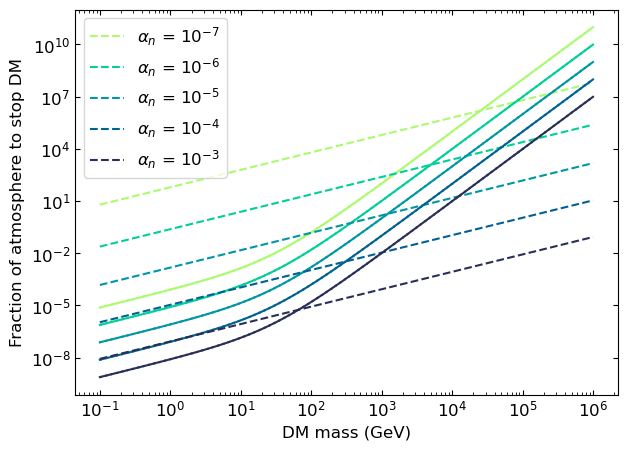

In [ ]:
colors = ['#acfa70', '#00cf97', '#0097a3', '#006290', '#292f56']
alpha_n_labels = [r'$10^{-7}$', r'$10^{-6}$', r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$']

for i in range(5):
    plt.plot(mx_list/1e9, stop_fractions_classical[i], '--', color=colors[i], label=fr'$\alpha_n$ = {alpha_n_labels[i]}')
    plt.plot(mx_list/1e9, stop_fractions_point[i], ':', color=colors[i])
    plt.plot(mx_list/1e9, stop_fractions_nugget[i], color=colors[i])


plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('DM mass (GeV)', fontsize=12)
plt.ylabel('Fraction of atmosphere to stop DM', fontsize=12)